<a href="https://colab.research.google.com/github/Sakshi3028/Local-Repo/blob/main/Multiclass%20classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [7]:
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [10]:
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')  # 10 classes
])

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9032 - loss: 0.3132 - val_accuracy: 0.9417 - val_loss: 0.1837
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9444 - loss: 0.1817 - val_accuracy: 0.9647 - val_loss: 0.1130
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9530 - loss: 0.1510 - val_accuracy: 0.9662 - val_loss: 0.1077
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9564 - loss: 0.1371 - val_accuracy: 0.9676 - val_loss: 0.1103
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9611 - loss: 0.1236 - val_accuracy: 0.9710 - val_loss: 0.0976
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9626 - loss: 0.1175 - val_accuracy: 0.9738 - val_loss: 0.0842
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9644 - loss: 0.1100 - val_accuracy: 0.9756 - val_loss: 0.0812
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9665 - loss: 0.1034 - 

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9781 - loss: 0.0706
Test Accuracy: 0.9781000018119812


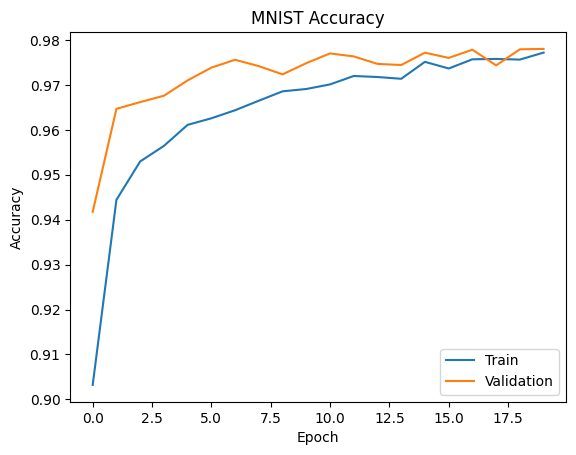

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('MNIST Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()